# COGNIFYZ TECHNOLOGIES - DATA SCIENCE INTERNSHIP
## Level 1: Tasks 1, 2 and 3
### Dataset: Zomato Restaurant Dataset

This notebook performs:
1. **Task 1:** Data Exploration and Preprocessing
2. **Task 2:** Descriptive Analysis
3. **Task 3:** Geospatial Analysis

## 1. Import Libraries



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


try:
    import folium
except ImportError:
    folium = None

from pathlib import Path

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

## 2. Load Dataset

In [2]:

BASE_DIR = Path.cwd()
FILE = BASE_DIR / 'Dataset.csv'

df = pd.read_csv(FILE)

print('=' * 60)
print('DATASET LOADED')
print('=' * 60)
print('Rows and columns:', df.shape)
print('\nColumn names:')
print(df.columns.tolist())
print('\nFirst 5 rows:')
display(df.head())

DATASET LOADED
Rows and columns: (9551, 27)

Column names:
['Restaurant_ID', 'Restaurant_Name', 'Country_Code', 'City', 'Address', 'Locality', 'Locality_Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average_Cost_for_two', 'Currency', 'Has_Table_booking', 'Has_Online_delivery', 'Is_delivering_now', 'Switch_to_order_menu', 'Price_range', 'Aggregate_rating', 'Rating_color', 'Rating_text', 'Votes', 'Restaurant_Name_Length', 'Address_Length', 'Cuisine_Count', 'Has_Table_Booking_Encoded', 'Has_Online_Delivery_Encoded', 'Votes_per_Rating_Point']

First 5 rows:


,Restaurant_ID,Restaurant_Name,Country_Code,City,Address,Locality,Locality_Verbose,Longitude,Latitude,Cuisines,Average_Cost_for_two,Currency,Has_Table_booking,Has_Online_delivery,Is_delivering_now,Switch_to_order_menu,Price_range,Aggregate_rating,Rating_color,Rating_text,Votes,Restaurant_Name_Length,Address_Length,Cuisine_Count,Has_Table_Booking_Encoded,Has_Online_Delivery_Encoded,Votes_per_Rating_Point
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314,16,71,3,1,0,65.416667
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591,16,67,1,1,0,131.333333
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270,22,56,4,1,0,61.363636
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365,4,70,2,0,0,74.489796
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229,11,64,2,1,0,47.708333


## 3. Standardize Column Names

In [3]:
df.columns = (
    df.columns
      .str.strip()
      .str.replace(' ', '_')
      .str.replace('/', '_')
      .str.replace('(', '', regex=False)
      .str.replace(')', '', regex=False)
)

print('Standardized column names:')
print(df.columns.tolist())

Standardized column names:
['Restaurant_ID', 'Restaurant_Name', 'Country_Code', 'City', 'Address', 'Locality', 'Locality_Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average_Cost_for_two', 'Currency', 'Has_Table_booking', 'Has_Online_delivery', 'Is_delivering_now', 'Switch_to_order_menu', 'Price_range', 'Aggregate_rating', 'Rating_color', 'Rating_text', 'Votes', 'Restaurant_Name_Length', 'Address_Length', 'Cuisine_Count', 'Has_Table_Booking_Encoded', 'Has_Online_Delivery_Encoded', 'Votes_per_Rating_Point']


# TASK 1: DATA EXPLORATION AND PREPROCESSING

In [4]:
print('=' * 60)
print('LEVEL 1 - TASK 1: DATA EXPLORATION AND PREPROCESSING')
print('=' * 60)

print('\nShape:', df.shape)

print('\nData types:')
print(df.dtypes)

print('\nMissing values:')
display(df.isnull().sum().sort_values(ascending=False).to_frame('Missing_Values'))

LEVEL 1 - TASK 1: DATA EXPLORATION AND PREPROCESSING

Shape: (9551, 27)

Data types:
Restaurant_ID                    int64
Restaurant_Name                    str
Country_Code                     int64
City                               str
Address                            str
Locality                           str
Locality_Verbose                   str
Longitude                      float64
Latitude                       float64
Cuisines                           str
Average_Cost_for_two             int64
Currency                           str
Has_Table_booking                  str
Has_Online_delivery                str
Is_delivering_now                  str
Switch_to_order_menu               str
Price_range                      int64
Aggregate_rating               float64
Rating_color                       str
Rating_text                        str
Votes                            int64
Restaurant_Name_Length           int64
Address_Length                   int64
Cuisine_Count     

,Missing_Values
Votes_per_Rating_Point,2148
Cuisines,9
Restaurant_Name,0
Country_Code,0
City,0
Locality,0
Address,0
Locality_Verbose,0
Longitude,0
Latitude,0


### 4. Convert Common Numeric Columns

In [5]:
numeric_candidates = [
    'Aggregate_rating', 'Votes', 'Price_range',
    'Latitude', 'Longitude', 'Country_Code'
]

for col in numeric_candidates:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print('Numeric conversion completed.')

Numeric conversion completed.


### 5. Remove Duplicate Rows

In [6]:
before = len(df)
df = df.drop_duplicates().copy()
print(f'Duplicate rows removed: {before - len(df)}')
print('Rows after removing duplicates:', len(df))

Duplicate rows removed: 0
Rows after removing duplicates: 9551


### 6. Handle Missing Values

In [7]:
# Numeric columns -> median
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# Categorical columns -> mode
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().any():
        mode = df[col].mode()
        if len(mode) > 0:
            df[col] = df[col].fillna(mode.iloc[0])

print('Missing values after preprocessing:')
display(df.isnull().sum().sort_values(ascending=False).head(15).to_frame('Missing_Values'))

Missing values after preprocessing:


C:\Windows\Temp\ipykernel_3468\2302611679.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


,Missing_Values
Restaurant_ID,0
Restaurant_Name,0
Country_Code,0
City,0
Address,0
Locality,0
Locality_Verbose,0
Longitude,0
Latitude,0
Cuisines,0


### 7. Aggregate Rating Distribution

Aggregate rating statistics:


,Aggregate_rating
count,9551.000000
mean,2.666370
std,1.516378
min,0.000000
25%,2.500000
50%,3.200000
75%,3.700000
max,4.900000


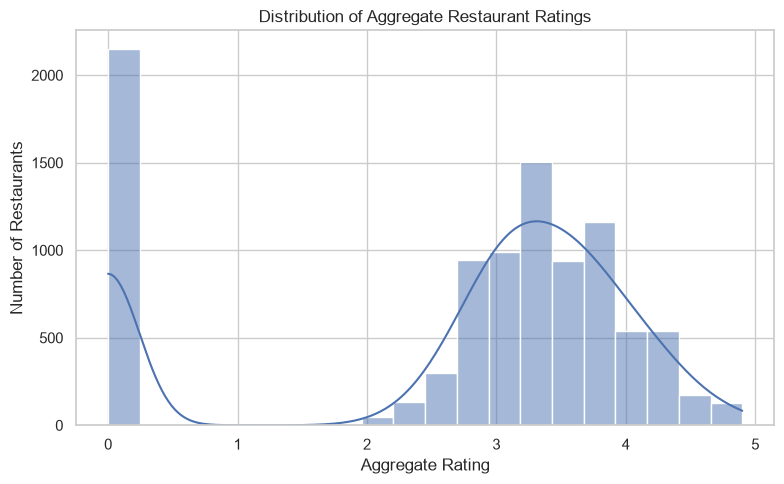

In [8]:
if 'Aggregate_rating' in df.columns:
    print('Aggregate rating statistics:')
    display(df['Aggregate_rating'].describe().to_frame())

    plt.figure(figsize=(8, 5))
    sns.histplot(df['Aggregate_rating'], bins=20, kde=True)
    plt.title('Distribution of Aggregate Restaurant Ratings')
    plt.xlabel('Aggregate Rating')
    plt.ylabel('Number of Restaurants')
    plt.tight_layout()
    plt.show()

### 8. Rating Group Distribution

In [9]:
if 'Aggregate_rating' in df.columns:
    bins = [-0.01, 2, 3, 4, 5]
    labels = ['0-2', '2-3', '3-4', '4-5']
    rating_groups = pd.cut(df['Aggregate_rating'], bins=bins, labels=labels)

    print('Rating group distribution:')
    display(rating_groups.value_counts().sort_index().to_frame('Count'))

    print('Rating group percentage:')
    display((rating_groups.value_counts(normalize=True).sort_index() * 100).round(2).to_frame('Percentage'))

Rating group distribution:


,Count
Aggregate_rating,
0-2,2158
2-3,1891
3-4,4388
4-5,1114


Rating group percentage:


,Percentage
Aggregate_rating,
0-2,22.59
2-3,19.80
3-4,45.94
4-5,11.66


# TASK 2: DESCRIPTIVE ANALYSIS

In [10]:
print('=' * 60)
print('LEVEL 1 - TASK 2: DESCRIPTIVE ANALYSIS')
print('=' * 60)

print('\nNumerical descriptive statistics:')
display(df.describe(include=[np.number]).T)

LEVEL 1 - TASK 2: DESCRIPTIVE ANALYSIS

Numerical descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
Restaurant_ID,9551.0,9.051128e+06,8.791521e+06,53.000000,301962.500000,6.004089e+06,1.835229e+07,1.850065e+07
Country_Code,9551.0,1.836562e+01,5.675055e+01,1.000000,1.000000,1.000000e+00,1.000000e+00,2.160000e+02
Longitude,9551.0,6.412657e+01,4.146706e+01,-157.948486,77.081343,7.719196e+01,7.728201e+01,1.748321e+02
Latitude,9551.0,2.585438e+01,1.100794e+01,-41.330428,28.478713,2.857047e+01,2.864276e+01,5.597698e+01
Average_Cost_for_two,9551.0,1.199211e+03,1.612118e+04,0.000000,250.000000,4.000000e+02,7.000000e+02,8.000000e+05
Price_range,9551.0,1.804837e+00,9.056088e-01,1.000000,1.000000,2.000000e+00,2.000000e+00,4.000000e+00
Aggregate_rating,9551.0,2.666370e+00,1.516378e+00,0.000000,2.500000,3.200000e+00,3.700000e+00,4.900000e+00
Votes,9551.0,1.569097e+02,4.301691e+02,0.000000,5.000000,3.100000e+01,1.310000e+02,1.093400e+04
Restaurant_Name_Length,9551.0,1.524259e+01,6.941754e+00,2.000000,10.000000,1.400000e+01,1.900000e+01,6.300000e+01
Address_Length,9551.0,5.366307e+01,1.733313e+01,13.000000,41.000000,5.200000e+01,6.400000e+01,1.550000e+02


### 9. Mean, Median and Standard Deviation

In [11]:
num_cols = df.select_dtypes(include=np.number).columns

summary = pd.DataFrame({
    'Mean': df[num_cols].mean(),
    'Median': df[num_cols].median(),
    'Std_Dev': df[num_cols].std()
}).sort_index()

display(summary)

,Mean,Median,Std_Dev
Address_Length,5.366307e+01,5.200000e+01,1.733313e+01
Aggregate_rating,2.666370e+00,3.200000e+00,1.516378e+00
Average_Cost_for_two,1.199211e+03,4.000000e+02,1.612118e+04
Country_Code,1.836562e+01,1.000000e+00,5.675055e+01
Cuisine_Count,2.063658e+00,2.000000e+00,1.094072e+00
Has_Online_Delivery_Encoded,2.566223e-01,0.000000e+00,4.367920e-01
Has_Table_Booking_Encoded,1.212438e-01,0.000000e+00,3.264275e-01
Latitude,2.585438e+01,2.857047e+01,1.100794e+01
Longitude,6.412657e+01,7.719196e+01,4.146706e+01
Price_range,1.804837e+00,2.000000e+00,9.056088e-01


### 10. Country Analysis

In [12]:
if 'Country_Code' in df.columns:
    print('Top countries by number of restaurants:')
    display(df['Country_Code'].value_counts().head(10).to_frame('Restaurant_Count'))

Top countries by number of restaurants:


,Restaurant_Count
Country_Code,
1,8652
216,434
215,80
30,60
214,60
189,60
148,40
208,34
14,24


### 11. City Analysis

Top 10 cities by number of restaurants:


,Restaurant_Count
City,
New Delhi,5473
Gurgaon,1118
Noida,1080
Faridabad,251
Ghaziabad,25
Ahmedabad,21
Amritsar,21
Bhubaneshwar,21
Guwahati,21


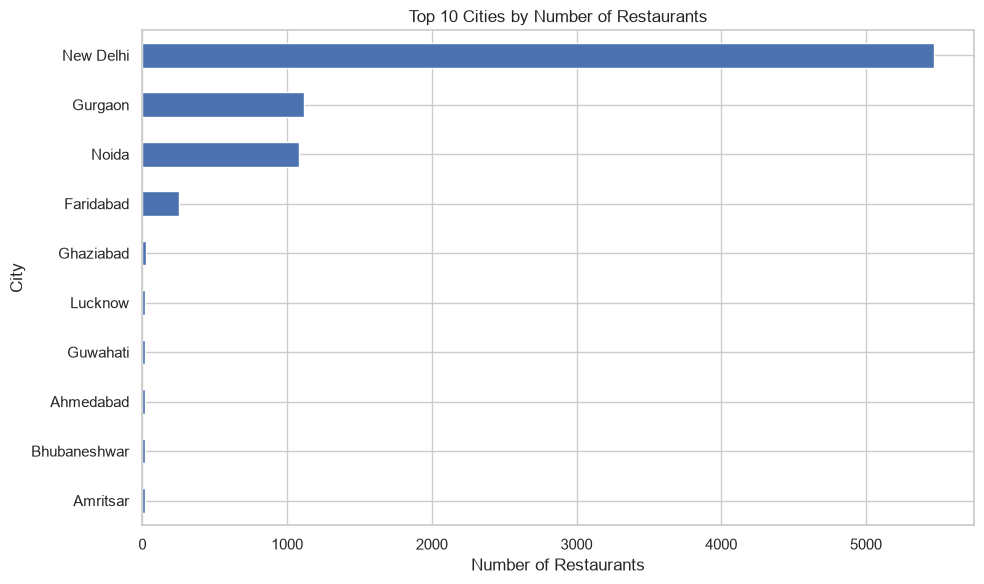

In [13]:
if 'City' in df.columns:
    city_counts = df['City'].value_counts()

    print('Top 10 cities by number of restaurants:')
    display(city_counts.head(10).to_frame('Restaurant_Count'))

    plt.figure(figsize=(10, 6))
    city_counts.head(10).sort_values().plot(kind='barh')
    plt.title('Top 10 Cities by Number of Restaurants')
    plt.xlabel('Number of Restaurants')
    plt.ylabel('City')
    plt.tight_layout()
    plt.show()

### 12. Cuisine Analysis

Top 15 cuisines:


,Restaurant_Count
Cuisines,
North Indian,3969
Chinese,2735
Fast Food,1986
Mughlai,995
Italian,764
Bakery,745
Continental,736
Cafe,703
Desserts,653


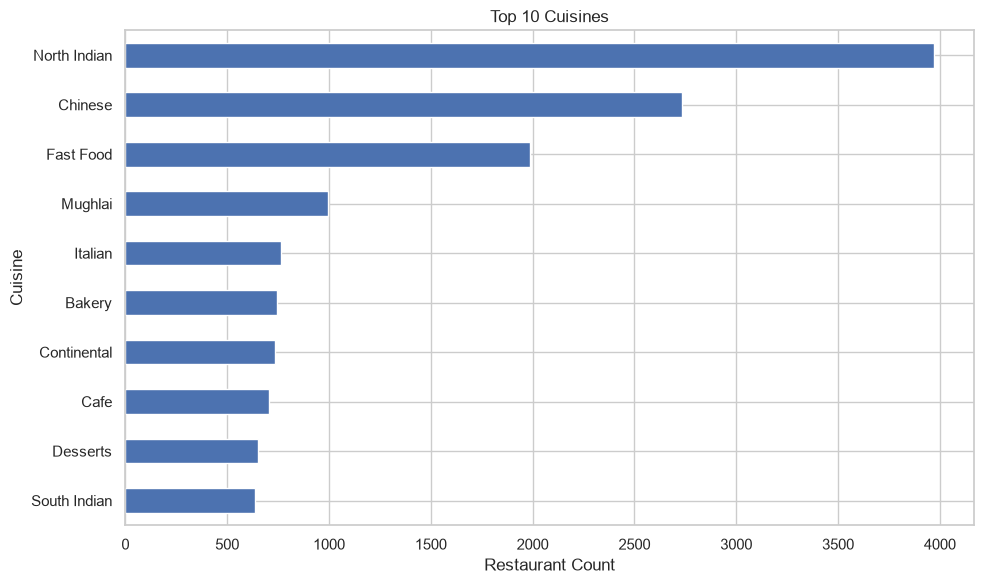

In [14]:
if 'Cuisines' in df.columns:
    cuisine_counts = (
        df['Cuisines']
        .dropna()
        .astype(str)
        .str.split(',')
        .explode()
        .str.strip()
        .value_counts()
    )

    print('Top 15 cuisines:')
    display(cuisine_counts.head(15).to_frame('Restaurant_Count'))

    plt.figure(figsize=(10, 6))
    cuisine_counts.head(10).sort_values().plot(kind='barh')
    plt.title('Top 10 Cuisines')
    plt.xlabel('Restaurant Count')
    plt.ylabel('Cuisine')
    plt.tight_layout()
    plt.show()

# TASK 3: GEOSPATIAL ANALYSIS

In [15]:
print('=' * 60)
print('LEVEL 1 - TASK 3: GEOSPATIAL ANALYSIS')
print('=' * 60)

if {'Latitude', 'Longitude'}.issubset(df.columns):
    geo = df[['Latitude', 'Longitude']].copy()

    print('Latitude summary:')
    display(geo['Latitude'].describe().to_frame())

    print('Longitude summary:')
    display(geo['Longitude'].describe().to_frame())

LEVEL 1 - TASK 3: GEOSPATIAL ANALYSIS
Latitude summary:


,Latitude
count,9551.000000
mean,25.854381
std,11.007935
min,-41.330428
25%,28.478713
50%,28.570469
75%,28.642758
max,55.976980


Longitude summary:


,Longitude
count,9551.000000
mean,64.126574
std,41.467058
min,-157.948486
25%,77.081343
50%,77.191964
75%,77.282006
max,174.832089


### 13. Geographical Distribution Scatter Plot

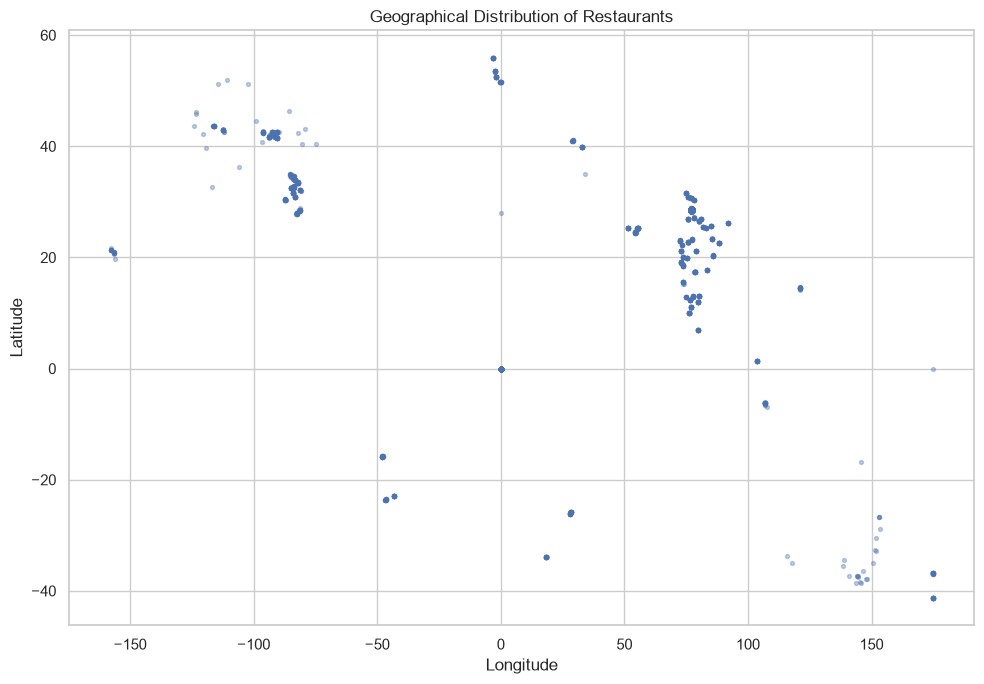

In [16]:
if {'Latitude', 'Longitude'}.issubset(df.columns):
    plt.figure(figsize=(10, 7))
    plt.scatter(
        df['Longitude'],
        df['Latitude'],
        s=8,
        alpha=0.35
    )
    plt.title('Geographical Distribution of Restaurants')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.tight_layout()
    plt.show()

### 14. Interactive Restaurant Map

In [17]:
if {'Latitude', 'Longitude'}.issubset(df.columns):
    if folium is not None:
        sample = df.dropna(subset=['Latitude', 'Longitude']).copy()
        sample = sample.sample(min(2000, len(sample)), random_state=42)

        center = [
            sample['Latitude'].mean(),
            sample['Longitude'].mean()
        ]

        restaurant_map = folium.Map(location=center, zoom_start=2)

        for _, row in sample.iterrows():
            folium.CircleMarker(
                location=[row['Latitude'], row['Longitude']],
                radius=2,
                popup=str(row.get('Restaurant_Name', 'Restaurant')),
                fill=True
            ).add_to(restaurant_map)

        display(restaurant_map)
        restaurant_map.save('restaurant_locations.html')
        print('Interactive map saved as: restaurant_locations.html')
    else:
        print('Install folium for the interactive map: %pip install folium')

Interactive map saved as: restaurant_locations.html


### 15. Location vs Rating Analysis

In [18]:
if {'City', 'Aggregate_rating'}.issubset(df.columns):
    city_rating = (
        df.groupby('City')['Aggregate_rating']
        .agg(['count', 'mean'])
        .sort_values('count', ascending=False)
    )

    print('Average rating for cities with at least 50 restaurants:')
    display(
        city_rating[city_rating['count'] >= 50]
        .sort_values('mean', ascending=False)
        .head(15)
    )

if {'Country_Code', 'Aggregate_rating'}.issubset(df.columns):
    country_rating = (
        df.groupby('Country_Code')['Aggregate_rating']
        .agg(['count', 'mean'])
        .sort_values('count', ascending=False)
    )

    print('Average rating by country (minimum 20 restaurants):')
    display(
        country_rating[country_rating['count'] >= 20]
        .sort_values('mean', ascending=False)
    )

Average rating for cities with at least 50 restaurants:


,count,mean
City,,
Gurgaon,1118,2.651431
New Delhi,5473,2.438845
Noida,1080,2.036204
Faridabad,251,1.866932


Average rating by country (minimum 20 restaurants):


,count,mean
Country_Code,,
162,22,4.468182
208,34,4.300000
94,21,4.295238
148,40,4.262500
214,60,4.233333
189,60,4.210000
215,80,4.087500
166,20,4.060000
216,434,4.004378


# Conclusion

The notebook completed the three Level 1 tasks:
- **Task 1:** Explored the dataset, standardized columns, converted numeric fields, removed duplicates, and handled missing values.
- **Task 2:** Performed descriptive analysis for numerical variables, countries, cities, and cuisines.
- **Task 3:** Analyzed restaurant coordinates, visualized geographical distribution, created an interactive map, and compared ratings by location.

## Final Status
**LEVEL 1 - TASKS 1, 2 AND 3 COMPLETE**